In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, nltk, os, glob, pickle
from utils import plot_style, norm01; plot_style('notebook');
import torch

* Generate continuous-valued stimulus matrix of shape `(n_stims=100, stim_dim=10)` across `n_events=10` events
* **Stimulus dimensions split into two roles:**
    * `event_feats` (5 dims): carry event identity — stable within an event, jitter around a fixed event template
    * `non_event_feats` (5 dims): autoregressive — OU-style AR(1) drift toward 0 (decay) or 1 (build) over the event
* **Narrative-level structure:** `prop_related_events=0.4` of events are "related" (templates close to a shared `narrative_template`); the rest have random templates
* **Event lengths:** sampled from a normal dist around `event_avg_len = n_stims/n_events`, min length 5, normalized to sum exactly to `n_stims`
* **Autoregression:** per event, `autoreg_direction ∈ {0=decay, 1=build}` drawn randomly; non_event_feats pulled toward target with `pull_strength = 1/event_len` plus Gaussian noise
* Visualize time-time stimulus correlation heatmap

In [2]:
# Parameters
rng = np.random.default_rng(42)
stim_dim, event_dim, n_events = 10, 5, 10
stim_noise = 0.05   # sd of gauss noise for each stim

# event_feats: dims shared by all events that carry identity (rest are autoregressive, see below)
event_feats     = rng.choice(stim_dim, event_dim, replace=False) # randomly select event_dim features from stim_dim
non_event_feats = np.setdiff1d(np.arange(stim_dim), event_feats) # dims that are not event_feats

# Narrative-level template — sparse: only event_feats are active, rest are 0
narrative_template = np.zeros(stim_dim)
narrative_template[event_feats] = rng.random(event_dim)

prop_related_events          = 0.4   # fraction of events with activity similar to narrative_template
related_event_template_noise = 0.01  # low noise → related event stays close to narrative_template


Related events: [0 5 7]


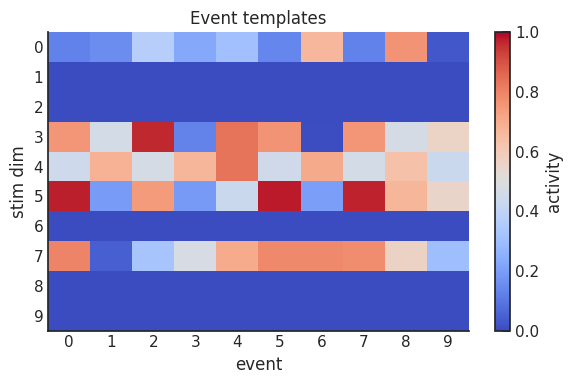

In [3]:
# generate event templates — sparse: only event_feats are active, rest are 0
event_relatedness = rng.random(n_events) < prop_related_events  # True = related to narrative
event_templates   = np.zeros((n_events, stim_dim))
for event_idx in range(n_events):
    if event_relatedness[event_idx]:
        event_templates[event_idx, event_feats] = np.clip(narrative_template[event_feats] + rng.normal(0, related_event_template_noise, event_dim), 0, 1)
    else:
        event_templates[event_idx, event_feats] = rng.random(event_dim)  # completely random activity

print(f"Related events: {np.where(event_relatedness)[0]}")

fig, ax = plt.subplots(figsize=(6,4))
ax.set(title='Event templates', xlabel='event', ylabel='stim dim', xticks=np.arange(n_events), yticks=np.arange(stim_dim))
im = ax.imshow(event_templates.T, aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='activity')
plt.tight_layout(); plt.show()


In [4]:
# generate event lengths via normal dist; normalize before int cast so no event overshoots n_stims
n_stims = 100
event_avg_len = n_stims / n_events
raw_lengths   = np.maximum(rng.normal(event_avg_len, event_avg_len * 0.2, n_events), 5)
event_lengths = (raw_lengths / raw_lengths.sum() * n_stims).astype(int)
event_lengths = np.clip(event_lengths, 5, None)  # minimum event length of 5
event_lengths[-1] = n_stims - event_lengths[:-1].sum()  # ensure exact sum = n_stims
print(f"event_lengths: {event_lengths}  (sum={event_lengths.sum()})")


event_lengths: [12  9  7  7  8 11 10 11  9 16]  (sum=100)


In [5]:
# Generate stimulus matrix with autoregressive event structure
autoreg_directions = []  # 0=decay (1→0), 1=build (0→1) per event
stim          = np.zeros((n_stims, stim_dim))
event_start_t = 0   # global timepoint where current event starts

for event_idx in range(n_events):
    event_len      = event_lengths[event_idx]
    event_template = event_templates[event_idx]

    direction = int(rng.integers(0, 2))
    autoreg_directions.append(direction)
    target        = 0.0 if direction == 0 else 1.0  # decay→0, build→1
    pull_strength = 1.0 / event_len  # norm by event_len

    # non_event_feats (autoreg feats): randomly initialized, then build/decay autoregressively
    x_prev = rng.random(len(non_event_feats))

    for event_t in range(event_len):
        t = event_start_t + event_t

        # OU-style AR(1): pull toward target proportional to remaining distance, plus noise
        dist_to_target = target - x_prev
        x_t            = x_prev + pull_strength * dist_to_target + rng.normal(0, stim_noise, len(non_event_feats))
        x_t            = np.clip(x_t, 0, 1)  # keep in valid range
        stim[t, non_event_feats] = x_t
        x_prev                   = x_t

        # event_feats: low variation between stims — jitter around template value
        stim[t, event_feats] = np.clip(event_template[event_feats] + rng.normal(0, stim_noise, len(event_feats)), 0, 1)

    event_start_t += event_len

autoreg_directions = np.array(autoreg_directions)
print(f"stim shape : {stim.shape}")
print(f"stim range : [{stim.min():.2f}, {stim.max():.2f}]")
print(f"Total timepoints filled: {event_start_t}")


stim shape : (100, 10)
stim range : [0.00, 1.00]
Total timepoints filled: 100


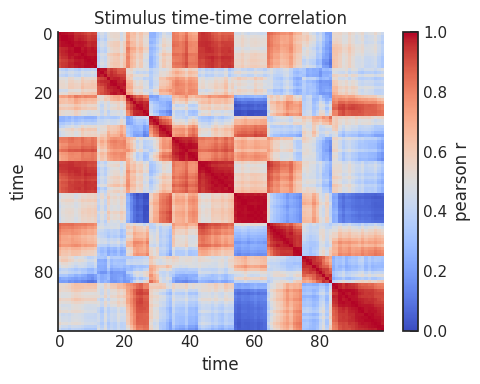

In [6]:

fig, ax = plt.subplots(figsize=(5,4))
ax.set(title='Stimulus time-time correlation', xlabel='time', ylabel='time')
im = ax.imshow(norm01(np.corrcoef(stim)), aspect='auto', cmap='coolwarm', vmin=0, vmax=1,
               origin='upper', interpolation='nearest')
plt.colorbar(im, ax=ax, label='pearson r')
plt.tight_layout()
plt.show()
